In [1]:
print("cell running successfully")

cell running successfully


In [2]:
# ============================================================================
# CELL 1: Dataset Preparation - Binary Classification (Tumor vs No Tumor)
# ============================================================================
# Model: EfficientNetV2-S
# Purpose: Convert segmentation dataset to classification format
# ============================================================================

import os
import random
import shutil
from tqdm import tqdm

print("🚀 Starting Dataset Preparation for EfficientNetV2-S Model")
print("="*70)

# Input directories (original images + masks)
IMG_DIR = "/kaggle/input/litsdataset2/images"
MASK_DIR = "/kaggle/input/litsdataset2/masks"

# Output directory (new classification folder structure)
OUT_DIR = "/kaggle/working/class_dataset"

# Create folders for train/val and labels (0 = no tumor, 1 = tumor)
print("📁 Creating directory structure...")
for split in ["train", "val"]:
    for cls in ["0", "1"]:
        os.makedirs(f"{OUT_DIR}/{split}/{cls}", exist_ok=True)
print("✅ Directory structure created!")

# Load all image file names and shuffle them
print("\n📂 Loading image files...")
images = [f for f in os.listdir(IMG_DIR) if f.endswith(".png")]
random.seed(42)  # For reproducibility
random.shuffle(images)
print(f"✅ Total images found: {len(images)}")

# 80-20 split for train and validation
split_idx = int(len(images) * 0.8)
train_files = images[:split_idx]
val_files = images[split_idx:]

print(f"\n📊 Dataset Split:")
print(f"   Train: {len(train_files)} images")
print(f"   Val:   {len(val_files)} images")

# Simple tumor detection based on mask file size
def is_tumor(mask_path):
    """Check if image contains tumor based on mask file size"""
    return os.path.getsize(mask_path) > 1200

# Process and copy images into class folders
def process_files(files, split):
    """Process and organize files into classification structure"""
    tumor_count = 0
    no_tumor_count = 0
    
    print(f"\n🔄 Processing {split} set...")
    for f in tqdm(files, desc=f"Processing {split}", ncols=100):
        img_path = os.path.join(IMG_DIR, f)
        mask_path = os.path.join(MASK_DIR, f)
        
        # Determine label
        if is_tumor(mask_path):
            label = "1"
            tumor_count += 1
        else:
            label = "0"
            no_tumor_count += 1
        
        # Copy to destination
        dst = os.path.join(OUT_DIR, split, label, f)
        shutil.copyfile(img_path, dst)
    
    print(f"   ✅ {split.upper()} - Tumor: {tumor_count}, No Tumor: {no_tumor_count}")
    return tumor_count, no_tumor_count

# Process train and validation sets
train_tumor, train_no_tumor = process_files(train_files, "train")
val_tumor, val_no_tumor = process_files(val_files, "val")

# Summary
print("\n" + "="*70)
print("📊 DATASET PREPARATION SUMMARY")
print("="*70)
print(f"Training Set:")
print(f"   Class 0 (No Tumor): {train_no_tumor}")
print(f"   Class 1 (Tumor):    {train_tumor}")
print(f"   Total:              {train_no_tumor + train_tumor}")
print(f"\nValidation Set:")
print(f"   Class 0 (No Tumor): {val_no_tumor}")
print(f"   Class 1 (Tumor):    {val_tumor}")
print(f"   Total:              {val_no_tumor + val_tumor}")
print("="*70)
print("✅ Dataset preparation COMPLETE!")
print("="*70)

🚀 Starting Dataset Preparation for EfficientNetV2-S Model
📁 Creating directory structure...
✅ Directory structure created!

📂 Loading image files...
✅ Total images found: 58638

📊 Dataset Split:
   Train: 46910 images
   Val:   11728 images

🔄 Processing train set...


Processing train: 100%|███████████████████████████████████████| 46910/46910 [13:09<00:00, 59.38it/s]


   ✅ TRAIN - Tumor: 9571, No Tumor: 37339

🔄 Processing val set...


Processing val: 100%|█████████████████████████████████████████| 11728/11728 [03:12<00:00, 60.88it/s]

   ✅ VAL - Tumor: 2397, No Tumor: 9331

📊 DATASET PREPARATION SUMMARY
Training Set:
   Class 0 (No Tumor): 37339
   Class 1 (Tumor):    9571
   Total:              46910

Validation Set:
   Class 0 (No Tumor): 9331
   Class 1 (Tumor):    2397
   Total:              11728
✅ Dataset preparation COMPLETE!


In [3]:
# ============================================================================
# CELL 2: Import Libraries and Configuration Setup
# ============================================================================
# Model: EfficientNetV2-S
# Purpose: Import all required libraries and set configurations
# ============================================================================

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from torch.cuda.amp import GradScaler, autocast
import timm
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, 
    roc_curve, auc, precision_recall_fscore_support,
    accuracy_score, roc_auc_score, f1_score
)
from sklearn.preprocessing import label_binarize
import warnings
import json
from collections import defaultdict
import time

warnings.filterwarnings('ignore')

print("🚀 EfficientNetV2-S Model Training Setup")
print("="*70)

# ---------------------------
# Device Configuration
# ---------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"💻 Device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# ---------------------------
# Hyperparameters
# ---------------------------
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 4
NUM_EPOCHS = 30  # Change to 20, 30, 50 as needed
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

print(f"\n⚙️ Hyperparameters:")
print(f"   Image Size:      {IMG_SIZE}x{IMG_SIZE}")
print(f"   Batch Size:      {BATCH_SIZE}")
print(f"   Epochs:          {NUM_EPOCHS}")
print(f"   Learning Rate:   {LEARNING_RATE}")
print(f"   Weight Decay:    {WEIGHT_DECAY}")

# ---------------------------
# Dataset Paths
# ---------------------------
DATA_DIR = "/kaggle/working/class_dataset"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR = os.path.join(DATA_DIR, "val")

print(f"\n📁 Dataset Paths:")
print(f"   Train: {TRAIN_DIR}")
print(f"   Val:   {VAL_DIR}")
print("="*70)

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

🚀 EfficientNetV2-S Model Training Setup
💻 Device: cuda
   GPU: Tesla T4
   Memory: 15.83 GB

⚙️ Hyperparameters:
   Image Size:      224x224
   Batch Size:      32
   Epochs:          30
   Learning Rate:   0.0001
   Weight Decay:    0.0001

📁 Dataset Paths:
   Train: /kaggle/working/class_dataset/train
   Val:   /kaggle/working/class_dataset/val


In [4]:
# ============================================================================
# CELL 3: Data Preparation and DataLoaders
# ============================================================================
# Model: EfficientNetV2-S
# Purpose: Create data transforms and prepare DataLoaders
# ============================================================================

print("📊 Preparing Data Transforms and DataLoaders")
print("="*70)

# ---------------------------
# Image Transforms
# ---------------------------
# Training transforms with augmentation
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225]),
])

# Validation transforms without augmentation
val_transforms = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.1)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225]),
])

print("✅ Transforms created!")

# ---------------------------
# Create Datasets
# ---------------------------
print("\n📂 Loading datasets...")
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=val_transforms)

NUM_CLASSES = len(train_dataset.classes)
class_names = train_dataset.classes

print(f"✅ Datasets loaded!")
print(f"   Classes: {class_names}")
print(f"   Number of classes: {NUM_CLASSES}")

# ---------------------------
# Create DataLoaders
# ---------------------------
print("\n🔄 Creating DataLoaders...")
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=NUM_WORKERS, 
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=NUM_WORKERS, 
    pin_memory=True
)

print("✅ DataLoaders created!")

# ---------------------------
# Dataset Statistics
# ---------------------------
print("\n" + "="*70)
print("📊 DATASET INFORMATION")
print("="*70)
print(f"Training samples:   {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Total samples:      {len(train_dataset) + len(val_dataset)}")
print(f"\nBatch Information:")
print(f"   Train batches:   {len(train_loader)}")
print(f"   Val batches:     {len(val_loader)}")
print("="*70)

# Calculate class distribution
train_class_counts = defaultdict(int)
for _, label in train_dataset.samples:
    train_class_counts[label] += 1

val_class_counts = defaultdict(int)
for _, label in val_dataset.samples:
    val_class_counts[label] += 1

print("\n📊 Class Distribution:")
print("-"*70)
print(f"{'Class':<20} {'Train':<15} {'Val':<15} {'Total':<15}")
print("-"*70)
for idx, class_name in enumerate(class_names):
    train_count = train_class_counts[idx]
    val_count = val_class_counts[idx]
    total_count = train_count + val_count
    print(f"{class_name:<20} {train_count:<15} {val_count:<15} {total_count:<15}")
print("-"*70)

📊 Preparing Data Transforms and DataLoaders
✅ Transforms created!

📂 Loading datasets...
✅ Datasets loaded!
   Classes: ['0', '1']
   Number of classes: 2

🔄 Creating DataLoaders...
✅ DataLoaders created!

📊 DATASET INFORMATION
Training samples:   46910
Validation samples: 11728
Total samples:      58638

Batch Information:
   Train batches:   1466
   Val batches:     367

📊 Class Distribution:
----------------------------------------------------------------------
Class                Train           Val             Total          
----------------------------------------------------------------------
0                    37339           9331            46670          
1                    9571            2397            11968          
----------------------------------------------------------------------


In [6]:
# ============================================================================
# CELL 4: EfficientNetV2-S Model Architecture Setup
# ============================================================================
# Model: EfficientNetV2-S (Pre-trained on ImageNet)
# Purpose: Load and configure the model for binary classification
# ============================================================================

print("🏗️ Building EfficientNetV2-S Model")
print("="*70)

# ---------------------------
# Load Pre-trained Model
# ---------------------------
print("📥 Loading pre-trained EfficientNetV2-S from timm...")
model = timm.create_model(
    'tf_efficientnetv2_s',  # EfficientNetV2-S
    pretrained=True,
    num_classes=NUM_CLASSES
)

print("✅ Model loaded successfully!")

# ---------------------------
# Model Summary
# ---------------------------
print(f"\n📋 Model Information:")
print(f"   Architecture:  EfficientNetV2-S")
print(f"   Pre-trained:   Yes (ImageNet)")
print(f"   Input size:    {IMG_SIZE}x{IMG_SIZE}")
print(f"   Output classes: {NUM_CLASSES}")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n🔢 Model Parameters:")
print(f"   Total parameters:     {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")

# Move model to device
model = model.to(device)
print(f"\n✅ Model moved to {device}")

# ---------------------------
# Loss Function and Optimizer
# ---------------------------
print("\n⚙️ Configuring training components...")

# Loss function
criterion = nn.CrossEntropyLoss()
print(f"   Loss Function:  CrossEntropyLoss")

# Optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)
print(f"   Optimizer:      AdamW")
print(f"   Learning Rate:  {LEARNING_RATE}")
print(f"   Weight Decay:   {WEIGHT_DECAY}")

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='max',
    factor=0.5,
    patience=2
)
print(f"   LR Scheduler:   ReduceLROnPlateau (mode=max, factor=0.5, patience=2)")

# Mixed precision training
scaler = GradScaler()
print(f"   Mixed Precision: Enabled")

print("="*70)
print("✅ Model setup COMPLETE!")
print("="*70)

🏗️ Building EfficientNetV2-S Model
📥 Loading pre-trained EfficientNetV2-S from timm...
✅ Model loaded successfully!

📋 Model Information:
   Architecture:  EfficientNetV2-S
   Pre-trained:   Yes (ImageNet)
   Input size:    224x224
   Output classes: 2

🔢 Model Parameters:
   Total parameters:     20,180,050
   Trainable parameters: 20,180,050

✅ Model moved to cuda

⚙️ Configuring training components...
   Loss Function:  CrossEntropyLoss
   Optimizer:      AdamW
   Learning Rate:  0.0001
   Weight Decay:   0.0001
   LR Scheduler:   ReduceLROnPlateau (mode=max, factor=0.5, patience=2)
   Mixed Precision: Enabled
✅ Model setup COMPLETE!


In [8]:
# ============================================================================
# CELL 5: Training and Validation Functions
# ============================================================================
# Model: EfficientNetV2-S
# Purpose: Define training and validation loops with metrics tracking
# ============================================================================

def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, epoch):
    """Train the model for one epoch"""
    model.train()
    
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    # Progress bar
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]", ncols=100)
    
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Mixed precision training
        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)
        
        # Backward pass
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        # Statistics
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        # Update progress bar
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    # Calculate epoch metrics
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_precision, epoch_recall, epoch_f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted', zero_division=0
    )
    
    return epoch_loss, epoch_acc, epoch_precision, epoch_recall, epoch_f1


def validate(model, val_loader, criterion, device, epoch):
    """Validate the model"""
    model.eval()
    
    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []
    
    # Progress bar
    pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Val]  ", ncols=100)
    
    with torch.no_grad():
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Get predictions and probabilities
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            running_loss += loss.item() * images.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
            # Update progress bar
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    # Calculate epoch metrics
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_precision, epoch_recall, epoch_f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted', zero_division=0
    )
    
    return epoch_loss, epoch_acc, epoch_precision, epoch_recall, epoch_f1, all_preds, all_labels, all_probs


print("✅ Training and Validation functions defined!")

✅ Training and Validation functions defined!


In [9]:
# ============================================================================
# CELL 6: Main Training Loop with Metrics Tracking
# ============================================================================
# Model: EfficientNetV2-S
# Purpose: Train the model and track all metrics for visualization
# ============================================================================

print("\n" + "="*70)
print("🚀 STARTING TRAINING - EfficientNetV2-S")
print("="*70)

# Initialize tracking variables
history = {
    'train_loss': [],
    'train_acc': [],
    'train_precision': [],
    'train_recall': [],
    'train_f1': [],
    'val_loss': [],
    'val_acc': [],
    'val_precision': [],
    'val_recall': [],
    'val_f1': []
}

best_val_acc = 0.0
best_val_f1 = 0.0
best_epoch = 0
best_model_state = None

# For storing best epoch predictions
best_predictions = None
best_labels = None
best_probs = None

# Training loop
start_time = time.time()

for epoch in range(NUM_EPOCHS):
    print(f"\n{'='*70}")
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"{'='*70}")
    
    # Train
    train_loss, train_acc, train_prec, train_rec, train_f1 = train_one_epoch(
        model, train_loader, criterion, optimizer, scaler, device, epoch
    )
    
    # Validate
    val_loss, val_acc, val_prec, val_rec, val_f1, val_preds, val_labels, val_probs = validate(
        model, val_loader, criterion, device, epoch
    )
    
    # Update learning rate
    scheduler.step(val_acc)
    
    # Save metrics
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_precision'].append(train_prec)
    history['train_recall'].append(train_rec)
    history['train_f1'].append(train_f1)
    
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_precision'].append(val_prec)
    history['val_recall'].append(val_rec)
    history['val_f1'].append(val_f1)
    
    # Print epoch results
    print(f"\n📊 Epoch {epoch+1} Results:")
    print(f"   Train - Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | Prec: {train_prec:.4f} | Rec: {train_rec:.4f} | F1: {train_f1:.4f}")
    print(f"   Val   - Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | Prec: {val_prec:.4f} | Rec: {val_rec:.4f} | F1: {val_f1:.4f}")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_val_f1 = val_f1
        best_epoch = epoch + 1
        best_model_state = model.state_dict().copy()
        best_predictions = val_preds
        best_labels = val_labels
        best_probs = val_probs
        print(f"   ⭐ New best model! Validation Accuracy: {val_acc:.4f}")

# Training completed
total_time = time.time() - start_time
print(f"\n{'='*70}")
print("✅ TRAINING COMPLETED!")
print(f"{'='*70}")
print(f"⏱️  Total Training Time: {total_time/60:.2f} minutes")
print(f"⭐ Best Epoch: {best_epoch}")
print(f"   Best Val Accuracy: {best_val_acc:.4f}")
print(f"   Best Val F1-Score: {best_val_f1:.4f}")
print(f"{'='*70}")

# Load best model
model.load_state_dict(best_model_state)
print("\n✅ Best model weights loaded!")


🚀 STARTING TRAINING - EfficientNetV2-S

Epoch 1/30


Epoch 1/30 [Val]  : 100%|████████████████████████████| 367/367 [00:38<00:00,  9.50it/s, loss=0.0463]



📊 Epoch 1 Results:
   Train - Loss: 0.2978 | Acc: 0.9334 | Prec: 0.9333 | Rec: 0.9334 | F1: 0.9333
   Val   - Loss: 0.0493 | Acc: 0.9797 | Prec: 0.9799 | Rec: 0.9797 | F1: 0.9798
   ⭐ New best model! Validation Accuracy: 0.9797

Epoch 2/30


Epoch 2/30 [Val]  : 100%|████████████████████████████| 367/367 [00:38<00:00,  9.66it/s, loss=0.0701]



📊 Epoch 2 Results:
   Train - Loss: 0.0955 | Acc: 0.9626 | Prec: 0.9623 | Rec: 0.9626 | F1: 0.9624
   Val   - Loss: 0.0386 | Acc: 0.9835 | Prec: 0.9835 | Rec: 0.9835 | F1: 0.9835
   ⭐ New best model! Validation Accuracy: 0.9835

Epoch 3/30


...


📊 Epoch 28 Results:
   Train - Loss: 0.0220 | Acc: 0.9910 | Prec: 0.9910 | Rec: 0.9910 | F1: 0.9910
   Val   - Loss: 0.0179 | Acc: 0.9940 | Prec: 0.9940 | Rec: 0.9940 | F1: 0.9940

Epoch 29/30


Epoch 29/30 [Val]  : 100%|███████████████████████████| 367/367 [00:38<00:00,  9.63it/s, loss=0.0000]



📊 Epoch 29 Results:
   Train - Loss: 0.0206 | Acc: 0.9915 | Prec: 0.9915 | Rec: 0.9915 | F1: 0.9915
   Val   - Loss: 0.0187 | Acc: 0.9936 | Prec: 0.9937 | Rec: 0.9936 | F1: 0.9936

Epoch 30/30


Epoch 30/30 [Val]  : 100%|███████████████████████████| 367/367 [00:37<00:00,  9.66it/s, loss=0.0002]


📊 Epoch 30 Results:
   Train - Loss: 0.0193 | Acc: 0.9923 | Prec: 0.9923 | Rec: 0.9923 | F1: 0.9923
   Val   - Loss: 0.0185 | Acc: 0.9939 | Prec: 0.9940 | Rec: 0.9939 | F1: 0.9940

✅ TRAINING COMPLETED!
⏱️  Total Training Time: 153.67 minutes
⭐ Best Epoch: 22
   Best Val Accuracy: 0.9940
   Best Val F1-Score: 0.9940

✅ Best model weights loaded!



📊 GENERATING COMPLETE EVALUATION & VISUALIZATIONS

📊 BEST EPOCH EVALUATION METRICS

⭐ Best Model Performance (Epoch 22):
----------------------------------------------------------------------
Metric               Class 0         Class 1        
----------------------------------------------------------------------
Precision (%)        99.60           98.62          
Recall (%)           99.65           98.46          
F1-Score (%)         99.62           98.54          
Support              9331            2397           
----------------------------------------------------------------------

Overall Metrics               
----------------------------------------------------------------------
Accuracy (%)                   99.40%

Macro Average:                
  Precision (%)                99.11%
  Recall (%)                   99.05%
  F1-Score (%)                 99.08%

Weighted Average:             
  Precision (%)                99.40%
  Recall (%)                   99.40%
  F1-

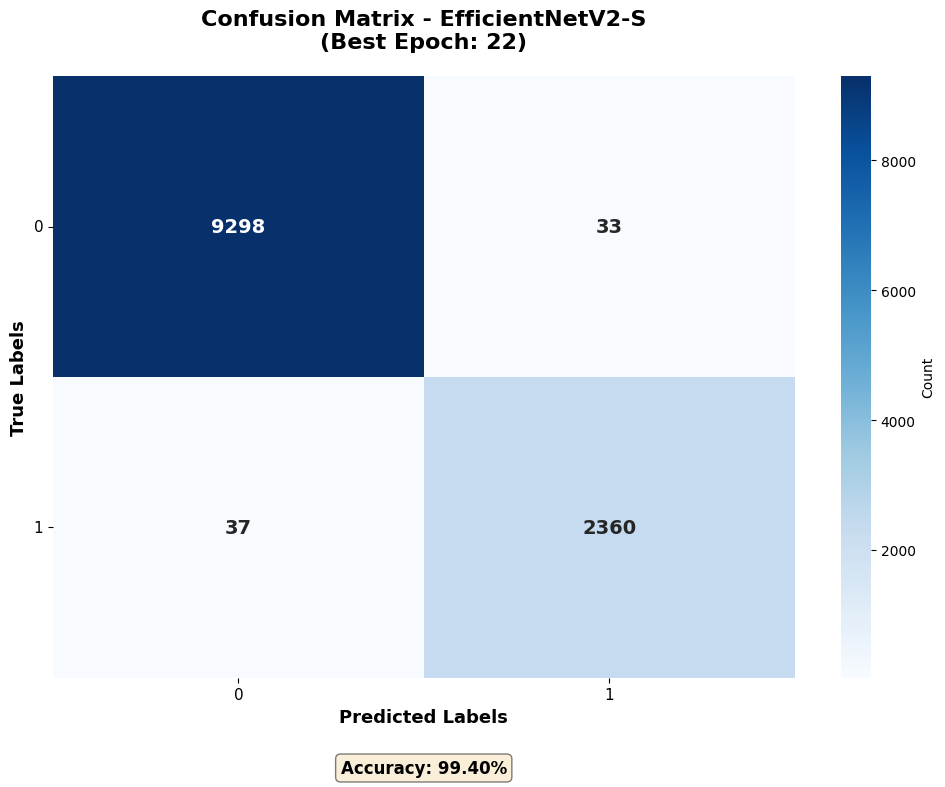

✅ Confusion Matrix saved!

📈 Generating Accuracy & Loss Curves...


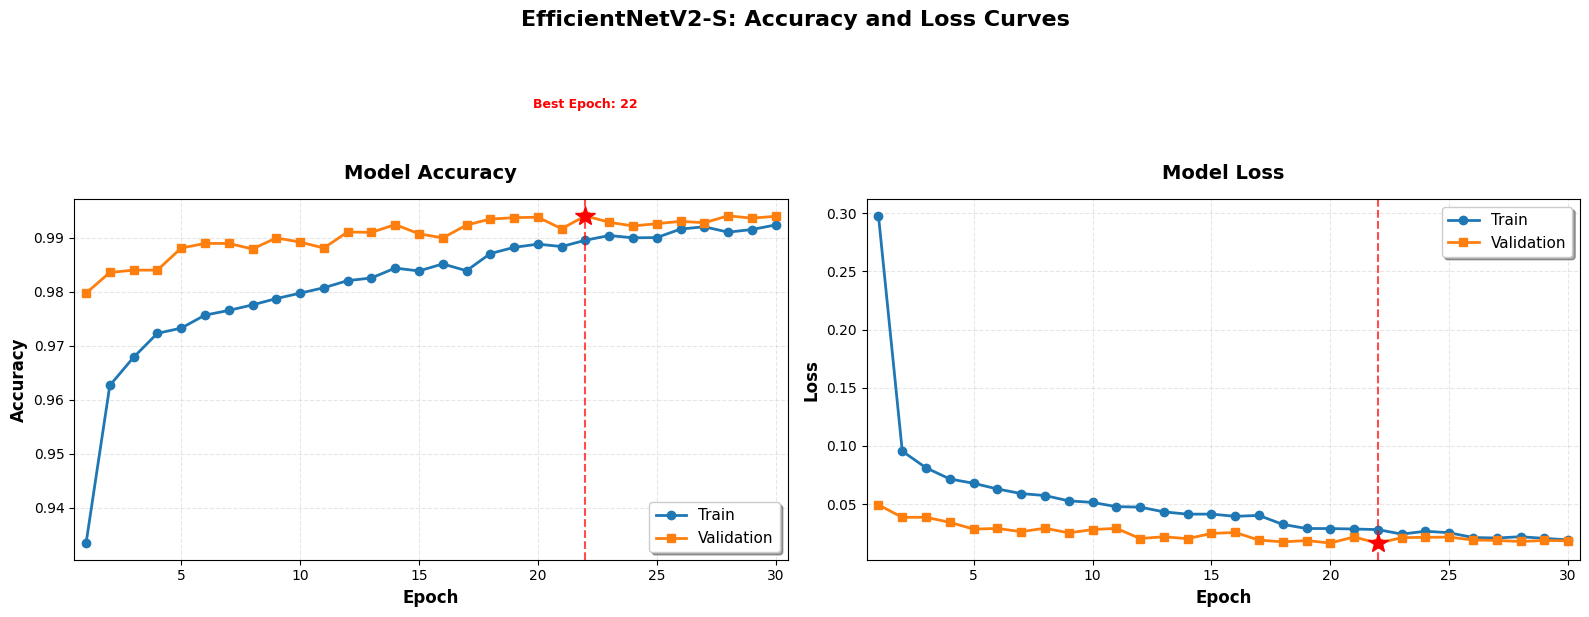

✅ Accuracy & Loss curves saved!

📈 Generating F1-Score Curve...


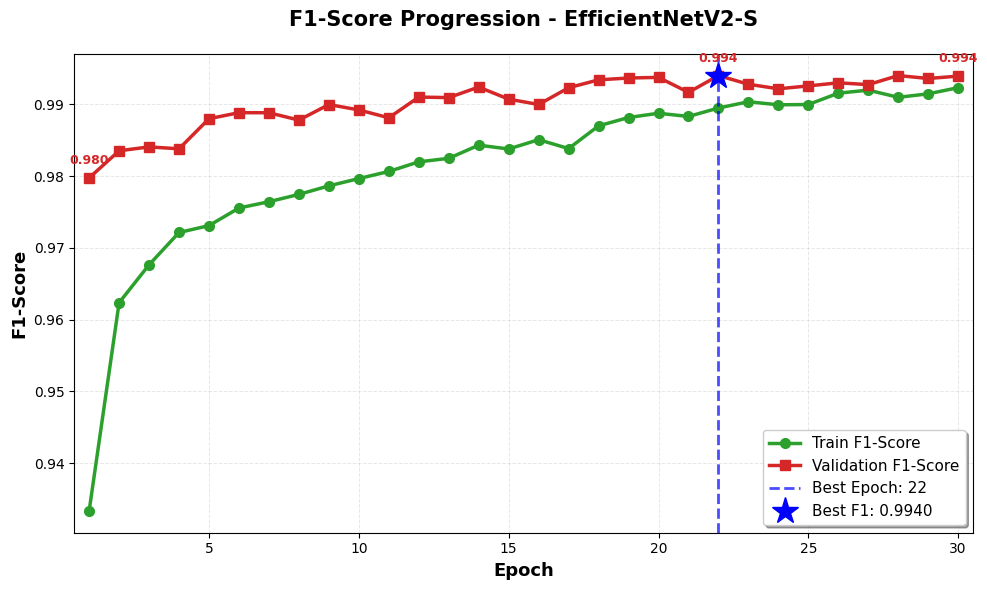

✅ F1-Score curve saved!

📊 Generating ROC Curve...


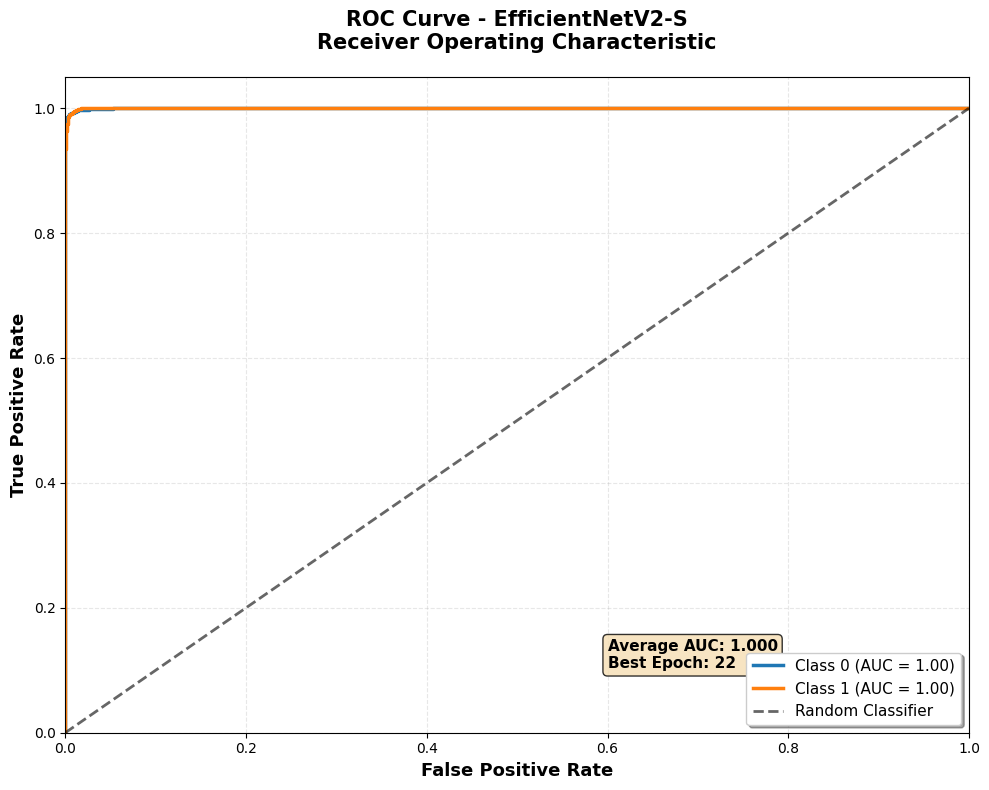

✅ ROC curve saved!

📊 ROC AUC Scores:
--------------------------------------------------
   Class 0: 0.9998 (99.98%)
   Class 1: 0.9998 (99.98%)

   Average AUC: 0.9998 (99.98%)
--------------------------------------------------

✅ ALL VISUALIZATIONS GENERATED SUCCESSFULLY!
Generated files:
  1. confusion_matrix_efficientnetv2s.png
  2. accuracy_loss_curves_efficientnetv2s.png
  3. f1_score_curve_efficientnetv2s.png
  4. roc_curve_efficientnetv2s.png


In [16]:
# ============================================================================
# CELL 7: Complete Evaluation Metrics & All Visualizations
# ============================================================================
# Model: EfficientNetV2-S
# Purpose: Generate evaluation table, confusion matrix, and all curves
# ============================================================================

print("\n" + "="*70)
print("📊 GENERATING COMPLETE EVALUATION & VISUALIZATIONS")
print("="*70)

# ============================================================================
# PART 1: Best Epoch Evaluation Metrics Table
# ============================================================================
print("\n" + "="*70)
print("📊 BEST EPOCH EVALUATION METRICS")
print("="*70)

# Get detailed classification report
report = classification_report(
    best_labels, 
    best_predictions, 
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

# Display metrics table
print(f"\n⭐ Best Model Performance (Epoch {best_epoch}):")
print("-"*70)
print(f"{'Metric':<20} {'Class 0':<15} {'Class 1':<15}")
print("-"*70)

for idx, class_name in enumerate(class_names):
    if idx == 0:
        class0_prec = report[class_name]['precision'] * 100
        class0_rec = report[class_name]['recall'] * 100
        class0_f1 = report[class_name]['f1-score'] * 100
        class0_sup = int(report[class_name]['support'])
    else:
        class1_prec = report[class_name]['precision'] * 100
        class1_rec = report[class_name]['recall'] * 100
        class1_f1 = report[class_name]['f1-score'] * 100
        class1_sup = int(report[class_name]['support'])

print(f"{'Precision (%)':<20} {class0_prec:<15.2f} {class1_prec:<15.2f}")
print(f"{'Recall (%)':<20} {class0_rec:<15.2f} {class1_rec:<15.2f}")
print(f"{'F1-Score (%)':<20} {class0_f1:<15.2f} {class1_f1:<15.2f}")
print(f"{'Support':<20} {class0_sup:<15} {class1_sup:<15}")
print("-"*70)

# Overall metrics
accuracy = report['accuracy'] * 100
macro_prec = report['macro avg']['precision'] * 100
macro_rec = report['macro avg']['recall'] * 100
macro_f1 = report['macro avg']['f1-score'] * 100
weighted_prec = report['weighted avg']['precision'] * 100
weighted_rec = report['weighted avg']['recall'] * 100
weighted_f1 = report['weighted avg']['f1-score'] * 100

print(f"\n{'Overall Metrics':<30}")
print("-"*70)
print(f"{'Accuracy (%)':<30} {accuracy:.2f}%")
print(f"\n{'Macro Average:':<30}")
print(f"  {'Precision (%)':<28} {macro_prec:.2f}%")
print(f"  {'Recall (%)':<28} {macro_rec:.2f}%")
print(f"  {'F1-Score (%)':<28} {macro_f1:.2f}%")
print(f"\n{'Weighted Average:':<30}")
print(f"  {'Precision (%)':<28} {weighted_prec:.2f}%")
print(f"  {'Recall (%)':<28} {weighted_rec:.2f}%")
print(f"  {'F1-Score (%)':<28} {weighted_f1:.2f}%")
print("-"*70)

# Calculate ROC AUC for binary classification
if NUM_CLASSES == 2:
    probs_positive = np.array(best_probs)[:, 1]
    roc_auc = roc_auc_score(best_labels, probs_positive)
    print(f"\n{'ROC AUC Score':<30} {roc_auc:.4f} ({roc_auc*100:.2f}%)")
    print("-"*70)

print("\n✅ Evaluation metrics calculated!")


# ============================================================================
# PART 2: Confusion Matrix
# ============================================================================
print("\n📊 Generating Confusion Matrix...")

cm = confusion_matrix(best_labels, best_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={'label': 'Count'},
    annot_kws={'size': 14, 'weight': 'bold'}
)

plt.title(f'Confusion Matrix - EfficientNetV2-S\n(Best Epoch: {best_epoch})', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Labels', fontsize=13, fontweight='bold')
plt.ylabel('True Labels', fontsize=13, fontweight='bold')
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)

accuracy_text = f'Accuracy: {best_val_acc*100:.2f}%'
plt.text(0.5, -0.15, accuracy_text, 
         ha='center', va='center', 
         transform=plt.gca().transAxes,
         fontsize=12, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('confusion_matrix_efficientnetv2s.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Confusion Matrix saved!")


# ============================================================================
# PART 3: Accuracy & Loss Curves
# ============================================================================
print("\n📈 Generating Accuracy & Loss Curves...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
epochs_range = range(1, NUM_EPOCHS + 1)

# Accuracy Curve
axes[0].plot(epochs_range, history['train_acc'], 'o-', 
             color='#1f77b4', linewidth=2, markersize=6, label='Train')
axes[0].plot(epochs_range, history['val_acc'], 's-', 
             color='#ff7f0e', linewidth=2, markersize=6, label='Validation')
axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold', pad=15)
axes[0].legend(loc='lower right', fontsize=11, frameon=True, shadow=True)
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].set_xlim(0.5, NUM_EPOCHS + 0.5)

best_val_acc_value = history['val_acc'][best_epoch-1]
axes[0].axvline(x=best_epoch, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
axes[0].plot(best_epoch, best_val_acc_value, 'r*', markersize=15)
axes[0].text(best_epoch, best_val_acc_value + 0.02, f'Best Epoch: {best_epoch}', 
             ha='center', fontsize=9, color='red', fontweight='bold')

# Loss Curve
axes[1].plot(epochs_range, history['train_loss'], 'o-', 
             color='#1f77b4', linewidth=2, markersize=6, label='Train')
axes[1].plot(epochs_range, history['val_loss'], 's-', 
             color='#ff7f0e', linewidth=2, markersize=6, label='Validation')
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold', pad=15)
axes[1].legend(loc='upper right', fontsize=11, frameon=True, shadow=True)
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].set_xlim(0.5, NUM_EPOCHS + 0.5)

best_val_loss_value = history['val_loss'][best_epoch-1]
axes[1].axvline(x=best_epoch, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
axes[1].plot(best_epoch, best_val_loss_value, 'r*', markersize=15)

fig.suptitle('EfficientNetV2-S: Accuracy and Loss Curves', 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('accuracy_loss_curves_efficientnetv2s.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Accuracy & Loss curves saved!")


# ============================================================================
# PART 4: F1-Score Curve
# ============================================================================
print("\n📈 Generating F1-Score Curve...")

plt.figure(figsize=(10, 6))

plt.plot(epochs_range, history['train_f1'], 'o-', 
         color='#2ca02c', linewidth=2.5, markersize=7, label='Train F1-Score')
plt.plot(epochs_range, history['val_f1'], 's-', 
         color='#d62728', linewidth=2.5, markersize=7, label='Validation F1-Score')

best_val_f1_value = history['val_f1'][best_epoch-1]
plt.axvline(x=best_epoch, color='blue', linestyle='--', alpha=0.7, linewidth=2, 
            label=f'Best Epoch: {best_epoch}')
plt.plot(best_epoch, best_val_f1_value, 'b*', markersize=20, 
         label=f'Best F1: {best_val_f1_value:.4f}')

plt.xlabel('Epoch', fontsize=13, fontweight='bold')
plt.ylabel('F1-Score', fontsize=13, fontweight='bold')
plt.title('F1-Score Progression - EfficientNetV2-S', 
          fontsize=15, fontweight='bold', pad=20)
plt.legend(loc='lower right', fontsize=11, frameon=True, shadow=True, fancybox=True)
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)
plt.xlim(0.5, NUM_EPOCHS + 0.5)

for i, (train_f1, val_f1) in enumerate(zip(history['train_f1'], history['val_f1']), 1):
    if i == best_epoch or i == 1 or i == NUM_EPOCHS:
        plt.annotate(f'{val_f1:.3f}', 
                    xy=(i, val_f1), 
                    xytext=(0, 10),
                    textcoords='offset points',
                    ha='center',
                    fontsize=9,
                    color='#d62728',
                    fontweight='bold')

plt.tight_layout()
plt.savefig('f1_score_curve_efficientnetv2s.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ F1-Score curve saved!")


# ============================================================================
# PART 5: ROC Curve
# ============================================================================
print("\n📊 Generating ROC Curve...")

y_score = np.array(best_probs)

# Handle binary vs multi-class
if NUM_CLASSES == 2:
    # For binary classification
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    # Class 0
    fpr[0], tpr[0], _ = roc_curve(best_labels, y_score[:, 0], pos_label=0)
    roc_auc[0] = auc(fpr[0], tpr[0])
    
    # Class 1
    fpr[1], tpr[1], _ = roc_curve(best_labels, y_score[:, 1], pos_label=1)
    roc_auc[1] = auc(fpr[1], tpr[1])
else:
    # For multi-class
    y_test_bin = label_binarize(best_labels, classes=range(NUM_CLASSES))
    
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(NUM_CLASSES):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, class_name in enumerate(class_names):
    plt.plot(fpr[i], tpr[i], 
             color=colors[i % len(colors)], 
             linewidth=2.5,
             label=f'Class {class_name} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=2, alpha=0.6, label='Random Classifier')

plt.xlabel('False Positive Rate', fontsize=13, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=13, fontweight='bold')
plt.title('ROC Curve - EfficientNetV2-S\nReceiver Operating Characteristic', 
          fontsize=15, fontweight='bold', pad=20)
plt.legend(loc='lower right', fontsize=11, frameon=True, shadow=True, fancybox=True)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

avg_auc = np.mean([roc_auc[i] for i in range(NUM_CLASSES)])
textstr = f'Average AUC: {avg_auc:.3f}\nBest Epoch: {best_epoch}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
plt.text(0.6, 0.15, textstr, fontsize=11, verticalalignment='top',
         bbox=props, fontweight='bold')

plt.tight_layout()
plt.savefig('roc_curve_efficientnetv2s.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ ROC curve saved!")

print(f"\n📊 ROC AUC Scores:")
print("-"*50)
for i, class_name in enumerate(class_names):
    print(f"   Class {class_name}: {roc_auc[i]:.4f} ({roc_auc[i]*100:.2f}%)")
print(f"\n   Average AUC: {avg_auc:.4f} ({avg_auc*100:.2f}%)")
print("-"*50)


# ============================================================================
# Summary
# ============================================================================
print("\n" + "="*70)
print("✅ ALL VISUALIZATIONS GENERATED SUCCESSFULLY!")
print("="*70)
print("Generated files:")
print("  1. confusion_matrix_efficientnetv2s.png")
print("  2. accuracy_loss_curves_efficientnetv2s.png")
print("  3. f1_score_curve_efficientnetv2s.png")
print("  4. roc_curve_efficientnetv2s.png")
print("="*70)


📊 Generating Final Performance Summary Table...


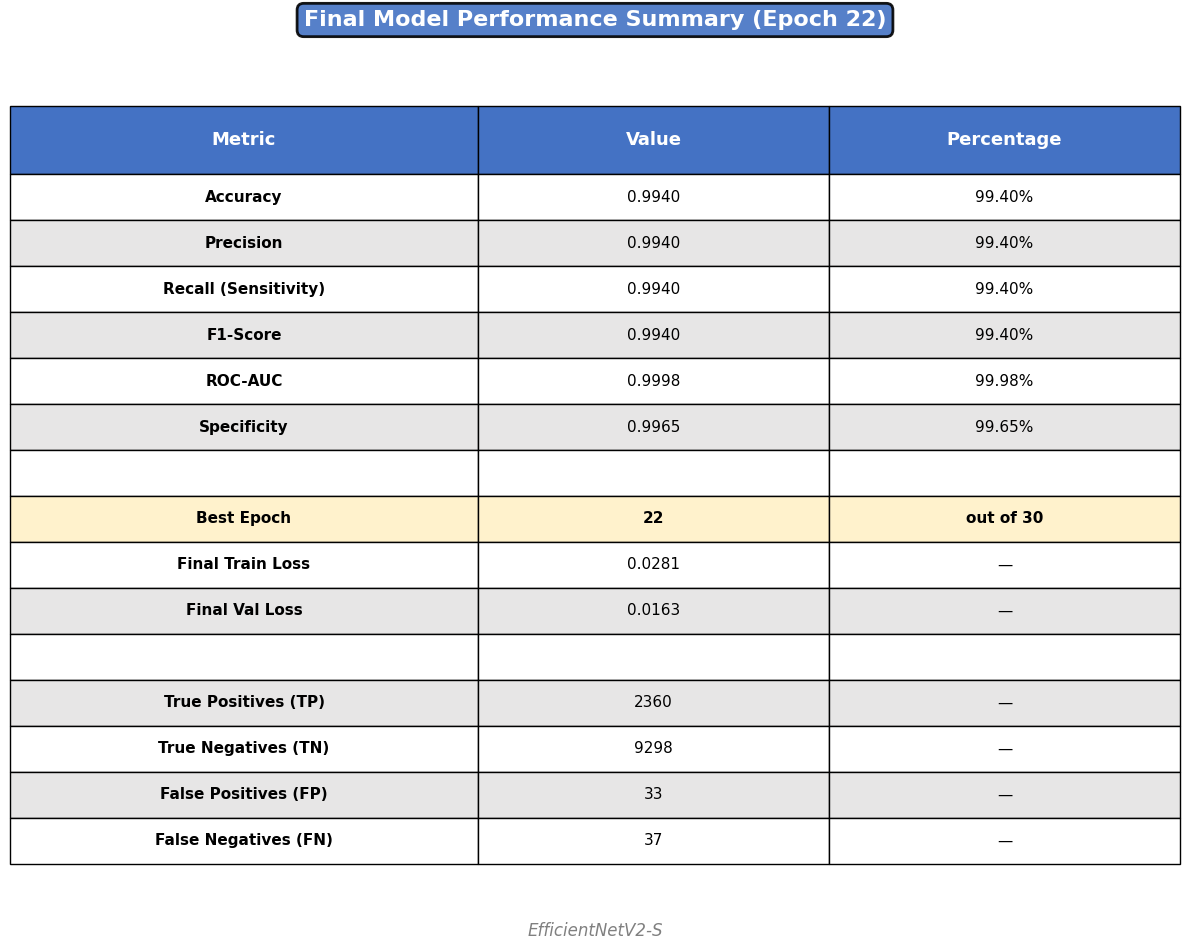

✅ Performance summary table saved as 'performance_summary_table.png'

                   FINAL MODEL PERFORMANCE SUMMARY (EPOCH 22)                   
Metric                         Value                Percentage          
--------------------------------------------------------------------------------
Accuracy                       0.9940               99.40%              
Precision                      0.9940               99.40%              
Recall (Sensitivity)           0.9940               99.40%              
F1-Score                       0.9940               99.40%              
ROC-AUC                        0.9998               99.98%              
Specificity                    0.9965               99.65%              
--------------------------------------------------------------------------------
Best Epoch                     22                   out of 30           
Final Train Loss               0.0281               —                   
Final Val Loss                

In [17]:
# ============================================================================
# Final Model Performance Summary Table
# ============================================================================
# Model: EfficientNetV2-S
# Purpose: Create a beautiful summary table with all metrics
# ============================================================================

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

print("\n📊 Generating Final Performance Summary Table...")

# Calculate confusion matrix values
tn, fp, fn, tp = cm.ravel() if NUM_CLASSES == 2 else (cm[0,0], cm[0,1], cm[1,0], cm[1,1])

# Calculate metrics
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

# Get best epoch metrics
idx = best_epoch - 1
best_accuracy = history['val_acc'][idx]
best_precision = history['val_precision'][idx]
best_recall = history['val_recall'][idx]
best_f1 = history['val_f1'][idx]
best_train_loss = history['train_loss'][idx]
best_val_loss = history['val_loss'][idx]

# Calculate ROC-AUC
if NUM_CLASSES == 2:
    probs_positive = np.array(best_probs)[:, 1]
    roc_auc_score_val = roc_auc_score(best_labels, probs_positive)
else:
    roc_auc_score_val = avg_auc

# Create data for table
table_data = {
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall (Sensitivity)',
        'F1-Score',
        'ROC-AUC',
        'Specificity',
        '',
        'Best Epoch',
        'Final Train Loss',
        'Final Val Loss',
        '',
        'True Positives (TP)',
        'True Negatives (TN)',
        'False Positives (FP)',
        'False Negatives (FN)'
    ],
    'Value': [
        f'{best_accuracy:.4f}',
        f'{best_precision:.4f}',
        f'{best_recall:.4f}',
        f'{best_f1:.4f}',
        f'{roc_auc_score_val:.4f}',
        f'{specificity:.4f}',
        '',
        f'{best_epoch}',
        f'{best_train_loss:.4f}',
        f'{best_val_loss:.4f}',
        '',
        f'{tp}',
        f'{tn}',
        f'{fp}',
        f'{fn}'
    ],
    'Percentage': [
        f'{best_accuracy*100:.2f}%',
        f'{best_precision*100:.2f}%',
        f'{best_recall*100:.2f}%',
        f'{best_f1*100:.2f}%',
        f'{roc_auc_score_val*100:.2f}%',
        f'{specificity*100:.2f}%',
        '',
        f'out of {NUM_EPOCHS}',
        '—',
        '—',
        '',
        '—',
        '—',
        '—',
        '—'
    ]
}

# Create DataFrame
df = pd.DataFrame(table_data)

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 10))
ax.axis('tight')
ax.axis('off')

# Create table
table = ax.table(cellText=df.values, colLabels=df.columns,
                cellLoc='center', loc='center',
                colWidths=[0.4, 0.3, 0.3])

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Header styling
for i in range(len(df.columns)):
    cell = table[(0, i)]
    cell.set_facecolor('#4472C4')
    cell.set_text_props(weight='bold', color='white', fontsize=13)
    cell.set_height(0.08)

# Data rows styling
for i in range(1, len(df) + 1):
    for j in range(len(df.columns)):
        cell = table[(i, j)]
        
        # Alternating row colors
        if df.iloc[i-1, 0] == '':  # Empty rows
            cell.set_facecolor('#FFFFFF')
        elif i % 2 == 0:
            cell.set_facecolor('#E7E6E6')
        else:
            cell.set_facecolor('#FFFFFF')
        
        # Bold text for metric names
        if j == 0 and df.iloc[i-1, 0] != '':
            cell.set_text_props(weight='bold', fontsize=11)
        else:
            cell.set_text_props(fontsize=11)
        
        # Special styling for best epoch row
        if 'Best Epoch' in str(df.iloc[i-1, 0]):
            cell.set_facecolor('#FFF2CC')
            cell.set_text_props(weight='bold')

# Add title
title_text = f'Final Model Performance Summary (Epoch {best_epoch})'
plt.text(0.5, 0.95, title_text, 
         ha='center', va='top', 
         transform=fig.transFigure,
         fontsize=16, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='#4472C4', 
                   edgecolor='black', linewidth=2, alpha=0.9),
         color='white')

# Add model name
model_text = 'EfficientNetV2-S'
plt.text(0.5, 0.02, model_text,
         ha='center', va='bottom',
         transform=fig.transFigure,
         fontsize=12, style='italic',
         color='gray')

plt.tight_layout()
plt.subplots_adjust(top=0.9, bottom=0.05)
plt.savefig('performance_summary_table.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

print("✅ Performance summary table saved as 'performance_summary_table.png'")

# Also print console version
print("\n" + "="*80)
print(f"{'FINAL MODEL PERFORMANCE SUMMARY (EPOCH ' + str(best_epoch) + ')':^80}")
print("="*80)
print(f"{'Metric':<30} {'Value':<20} {'Percentage':<20}")
print("-"*80)
for idx, row in df.iterrows():
    if row['Metric'] == '':
        print("-"*80)
    else:
        print(f"{row['Metric']:<30} {row['Value']:<20} {row['Percentage']:<20}")
print("="*80)


📈 Generating Comprehensive Metrics Curves...


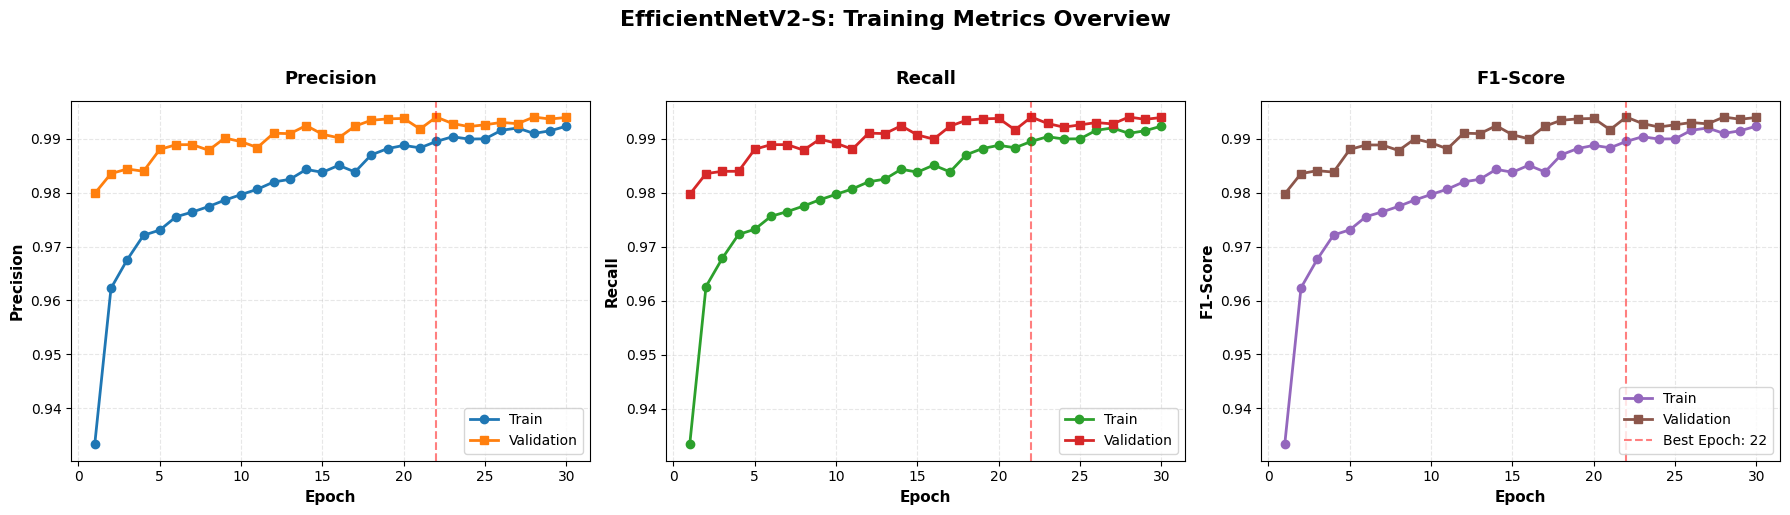

✅ Comprehensive metrics curves saved as 'all_metrics_curves_efficientnetv2s.png'

📊 Best Epoch (22) Metrics Summary:
------------------------------------------------------------
Metric               Train                Validation          
------------------------------------------------------------
Accuracy             0.9895 (98.95%)     0.9940 (99.40%)
Precision            0.9895 (98.95%)     0.9940 (99.40%)
Recall               0.9895 (98.95%)     0.9940 (99.40%)
F1-Score             0.9895 (98.95%)     0.9940 (99.40%)
Loss                 0.0281                 0.0163
------------------------------------------------------------


In [13]:
# ============================================================================
# CELL 12: Comprehensive Metrics Curves
# in sequence it is CELL 8
# ============================================================================
# Model: EfficientNetV2-S
# Purpose: Visualize all metrics (Precision, Recall, F1) together
# ============================================================================

print("\n📈 Generating Comprehensive Metrics Curves...")

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_range = range(1, NUM_EPOCHS + 1)

# -------------------- Precision Curve --------------------
axes[0].plot(epochs_range, history['train_precision'], 'o-', 
             color='#1f77b4', linewidth=2, markersize=6, label='Train')
axes[0].plot(epochs_range, history['val_precision'], 's-', 
             color='#ff7f0e', linewidth=2, markersize=6, label='Validation')

axes[0].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Precision', fontsize=11, fontweight='bold')
axes[0].set_title('Precision', fontsize=13, fontweight='bold', pad=12)
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].axvline(x=best_epoch, color='red', linestyle='--', alpha=0.5)

# -------------------- Recall Curve --------------------
axes[1].plot(epochs_range, history['train_recall'], 'o-', 
             color='#2ca02c', linewidth=2, markersize=6, label='Train')
axes[1].plot(epochs_range, history['val_recall'], 's-', 
             color='#d62728', linewidth=2, markersize=6, label='Validation')

axes[1].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Recall', fontsize=11, fontweight='bold')
axes[1].set_title('Recall', fontsize=13, fontweight='bold', pad=12)
axes[1].legend(loc='lower right', fontsize=10)
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].axvline(x=best_epoch, color='red', linestyle='--', alpha=0.5)

# -------------------- F1-Score Curve --------------------
axes[2].plot(epochs_range, history['train_f1'], 'o-', 
             color='#9467bd', linewidth=2, markersize=6, label='Train')
axes[2].plot(epochs_range, history['val_f1'], 's-', 
             color='#8c564b', linewidth=2, markersize=6, label='Validation')

axes[2].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[2].set_ylabel('F1-Score', fontsize=11, fontweight='bold')
axes[2].set_title('F1-Score', fontsize=13, fontweight='bold', pad=12)
axes[2].legend(loc='lower right', fontsize=10)
axes[2].grid(True, alpha=0.3, linestyle='--')
axes[2].axvline(x=best_epoch, color='red', linestyle='--', alpha=0.5, 
                label=f'Best Epoch: {best_epoch}')
axes[2].legend(loc='lower right', fontsize=10)

# Overall title
fig.suptitle('EfficientNetV2-S: Training Metrics Overview', 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('all_metrics_curves_efficientnetv2s.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Comprehensive metrics curves saved as 'all_metrics_curves_efficientnetv2s.png'")

# Print all metrics from best epoch
print(f"\n📊 Best Epoch ({best_epoch}) Metrics Summary:")
print("-"*60)
idx = best_epoch - 1
print(f"{'Metric':<20} {'Train':<20} {'Validation':<20}")
print("-"*60)
print(f"{'Accuracy':<20} {history['train_acc'][idx]:.4f} ({history['train_acc'][idx]*100:.2f}%){'':<4} {history['val_acc'][idx]:.4f} ({history['val_acc'][idx]*100:.2f}%)")
print(f"{'Precision':<20} {history['train_precision'][idx]:.4f} ({history['train_precision'][idx]*100:.2f}%){'':<4} {history['val_precision'][idx]:.4f} ({history['val_precision'][idx]*100:.2f}%)")
print(f"{'Recall':<20} {history['train_recall'][idx]:.4f} ({history['train_recall'][idx]*100:.2f}%){'':<4} {history['val_recall'][idx]:.4f} ({history['val_recall'][idx]*100:.2f}%)")
print(f"{'F1-Score':<20} {history['train_f1'][idx]:.4f} ({history['train_f1'][idx]*100:.2f}%){'':<4} {history['val_f1'][idx]:.4f} ({history['val_f1'][idx]*100:.2f}%)")
print(f"{'Loss':<20} {history['train_loss'][idx]:.4f}{'':<16} {history['val_loss'][idx]:.4f}")
print("-"*60)

In [14]:
# ============================================================================
# CELL 13: Save Model and Training History
# in sequence it is CELL 9
# ============================================================================
# Model: EfficientNetV2-S
# Purpose: Save trained model weights and training history for future use
# ============================================================================

print("\n💾 Saving model and training history...")

# Create directory for saved models
os.makedirs('/kaggle/working/saved_models', exist_ok=True)

# Save best model weights
model_save_path = '/kaggle/working/saved_models/efficientnetv2s_best_model.pth'
torch.save({
    'epoch': best_epoch,
    'model_state_dict': best_model_state,
    'optimizer_state_dict': optimizer.state_dict(),
    'best_val_acc': best_val_acc,
    'best_val_f1': best_val_f1,
    'num_classes': NUM_CLASSES,
    'class_names': class_names,
}, model_save_path)

print(f"✅ Model saved: {model_save_path}")

# Save training history as JSON
history_save_path = '/kaggle/working/saved_models/training_history.json'
with open(history_save_path, 'w') as f:
    json.dump(history, f, indent=4)

print(f"✅ Training history saved: {history_save_path}")

# Save training history as CSV for easy analysis
history_df = pd.DataFrame({
    'Epoch': list(range(1, NUM_EPOCHS + 1)),
    'Train_Loss': history['train_loss'],
    'Train_Acc': history['train_acc'],
    'Train_Precision': history['train_precision'],
    'Train_Recall': history['train_recall'],
    'Train_F1': history['train_f1'],
    'Val_Loss': history['val_loss'],
    'Val_Acc': history['val_acc'],
    'Val_Precision': history['val_precision'],
    'Val_Recall': history['val_recall'],
    'Val_F1': history['val_f1']
})

csv_save_path = '/kaggle/working/saved_models/training_history.csv'
history_df.to_csv(csv_save_path, index=False)
print(f"✅ Training history CSV saved: {csv_save_path}")

# Display training history table
print("\n📊 Training History Table:")
print("="*120)
print(history_df.to_string(index=False))
print("="*120)

# Summary
print(f"\n{'='*70}")
print("📦 SAVED FILES SUMMARY")
print(f"{'='*70}")
print(f"1. Model weights:        {model_save_path}")
print(f"2. History JSON:         {history_save_path}")
print(f"3. History CSV:          {csv_save_path}")
print(f"4. Confusion Matrix:     confusion_matrix_efficientnetv2s.png")
print(f"5. Accuracy/Loss:        accuracy_loss_curves_efficientnetv2s.png")
print(f"6. F1-Score Curve:       f1_score_curve_efficientnetv2s.png")
print(f"7. ROC Curve:            roc_curve_efficientnetv2s.png")
print(f"8. All Metrics:          all_metrics_curves_efficientnetv2s.png")
print(f"{'='*70}")

print("\n✅ All files saved successfully!")


💾 Saving model and training history...
✅ Model saved: /kaggle/working/saved_models/efficientnetv2s_best_model.pth
✅ Training history saved: /kaggle/working/saved_models/training_history.json
✅ Training history CSV saved: /kaggle/working/saved_models/training_history.csv

📊 Training History Table:
 Epoch  Train_Loss  Train_Acc  Train_Precision  Train_Recall  Train_F1  Val_Loss  Val_Acc  Val_Precision  Val_Recall   Val_F1
     1    0.297754   0.933362         0.933305      0.933362  0.933333  0.049341 0.979707       0.979855    0.979707 0.979766
     2    0.095516   0.962609         0.962261      0.962609  0.962362  0.038645 0.983544       0.983541    0.983544 0.983542
     3    0.081205   0.967832         0.967578      0.967832  0.967651  0.038715 0.983970       0.984395    0.983970 0.984086
     4    0.071605   0.972266         0.972098      0.972266  0.972154  0.034329 0.983970       0.983973    0.983970 0.983821
     5    0.067899   0.973225         0.973061      0.973225  0.973112 

In [15]:
# ============================================================================
# CELL 14: Final Summary Report
# in sequence it is CELL 10
# ============================================================================
# Model: EfficientNetV2-S
# Purpose: Generate comprehensive final report of the training process
# ============================================================================

print("\n" + "="*80)
print(" " * 20 + "🎯 EFFICIENTNETV2-S TRAINING SUMMARY REPORT")
print("="*80)

# Model Information
print("\n📌 MODEL INFORMATION:")
print("-"*80)
print(f"   Architecture:           EfficientNetV2-S (Pre-trained on ImageNet)")
print(f"   Total Parameters:       {total_params:,}")
print(f"   Trainable Parameters:   {trainable_params:,}")
print(f"   Input Size:             {IMG_SIZE}x{IMG_SIZE}")
print(f"   Number of Classes:      {NUM_CLASSES}")
print(f"   Class Names:            {', '.join(class_names)}")

# Training Configuration
print("\n⚙️ TRAINING CONFIGURATION:")
print("-"*80)
print(f"   Optimizer:              AdamW")
print(f"   Learning Rate:          {LEARNING_RATE}")
print(f"   Weight Decay:           {WEIGHT_DECAY}")
print(f"   Batch Size:             {BATCH_SIZE}")
print(f"   Number of Epochs:       {NUM_EPOCHS}")
print(f"   Device:                 {device}")
print(f"   Mixed Precision:        Enabled")
print(f"   LR Scheduler:           ReduceLROnPlateau")

# Dataset Information
print("\n📊 DATASET INFORMATION:")
print("-"*80)
print(f"   Training Samples:       {len(train_dataset)}")
print(f"   Validation Samples:     {len(val_dataset)}")
print(f"   Total Samples:          {len(train_dataset) + len(val_dataset)}")
print(f"   Train Batches:          {len(train_loader)}")
print(f"   Validation Batches:     {len(val_loader)}")

# Best Model Performance
print("\n⭐ BEST MODEL PERFORMANCE (Epoch {}):" .format(best_epoch))
print("-"*80)
idx = best_epoch - 1
print(f"   Validation Accuracy:    {history['val_acc'][idx]:.4f} ({history['val_acc'][idx]*100:.2f}%)")
print(f"   Validation Precision:   {history['val_precision'][idx]:.4f} ({history['val_precision'][idx]*100:.2f}%)")
print(f"   Validation Recall:      {history['val_recall'][idx]:.4f} ({history['val_recall'][idx]*100:.2f}%)")
print(f"   Validation F1-Score:    {history['val_f1'][idx]:.4f} ({history['val_f1'][idx]*100:.2f}%)")
print(f"   Validation Loss:        {history['val_loss'][idx]:.4f}")

# Training Progress
print("\n📈 TRAINING PROGRESS:")
print("-"*80)
print(f"{'Epoch':<8} {'Train Acc':<12} {'Val Acc':<12} {'Train Loss':<12} {'Val Loss':<12} {'Val F1':<12}")
print("-"*80)
for i in range(NUM_EPOCHS):
    marker = " ⭐" if i == best_epoch - 1 else ""
    print(f"{i+1:<8} {history['train_acc'][i]:<12.4f} {history['val_acc'][i]:<12.4f} "
          f"{history['train_loss'][i]:<12.4f} {history['val_loss'][i]:<12.4f} "
          f"{history['val_f1'][i]:<12.4f}{marker}")
print("-"*80)

# Improvement Summary
print("\n📊 IMPROVEMENT SUMMARY:")
print("-"*80)
initial_val_acc = history['val_acc'][0]
final_val_acc = history['val_acc'][-1]
improvement = (best_val_acc - initial_val_acc) * 100

print(f"   Initial Val Accuracy:   {initial_val_acc:.4f} ({initial_val_acc*100:.2f}%)")
print(f"   Best Val Accuracy:      {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"   Final Val Accuracy:     {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")
print(f"   Improvement:            {improvement:+.2f} percentage points")

# Confusion Matrix Summary
print("\n📋 CONFUSION MATRIX SUMMARY:")
print("-"*80)
tn, fp, fn, tp = cm.ravel() if NUM_CLASSES == 2 else (cm[0,0], cm[0,1], cm[1,0], cm[1,1])
print(f"   True Negatives (TN):    {tn}")
print(f"   False Positives (FP):   {fp}")
print(f"   False Negatives (FN):   {fn}")
print(f"   True Positives (TP):    {tp}")
print(f"   Total Predictions:      {tn + fp + fn + tp}")

# Calculate additional metrics
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"\n   Sensitivity (Recall):   {sensitivity:.4f} ({sensitivity*100:.2f}%)")
print(f"   Specificity:            {specificity:.4f} ({specificity*100:.2f}%)")

# Time Summary
print("\n⏱️ TIME SUMMARY:")
print("-"*80)
print(f"   Total Training Time:    {total_time/60:.2f} minutes ({total_time/3600:.2f} hours)")
print(f"   Time per Epoch:         {(total_time/NUM_EPOCHS)/60:.2f} minutes")

# Files Generated
print("\n💾 GENERATED FILES:")
print("-"*80)
print("   1. confusion_matrix_efficientnetv2s.png")
print("   2. accuracy_loss_curves_efficientnetv2s.png")
print("   3. f1_score_curve_efficientnetv2s.png")
print("   4. roc_curve_efficientnetv2s.png")
print("   5. all_metrics_curves_efficientnetv2s.png")
print("   6. efficientnetv2s_best_model.pth")
print("   7. training_history.json")
print("   8. training_history.csv")

# Recommendations
print("\n💡 RECOMMENDATIONS FOR NEXT STEPS:")
print("-"*80)
if best_val_acc >= 0.95:
    print("   ✅ Excellent performance! Model is ready for deployment.")
elif best_val_acc >= 0.90:
    print("   ✅ Good performance! Consider fine-tuning for better results.")
else:
    print("   ⚠️  Consider: More epochs, data augmentation, or different architecture.")

if abs(history['train_acc'][idx] - history['val_acc'][idx]) > 0.1:
    print("   ⚠️  High train-val gap detected. Consider regularization or more data.")
else:
    print("   ✅ Good generalization - train and validation metrics are aligned.")

print("\n" + "="*80)
print(" " * 30 + "✅ TRAINING COMPLETE!")
print("="*80)


                    🎯 EFFICIENTNETV2-S TRAINING SUMMARY REPORT

📌 MODEL INFORMATION:
--------------------------------------------------------------------------------
   Architecture:           EfficientNetV2-S (Pre-trained on ImageNet)
   Total Parameters:       20,180,050
   Trainable Parameters:   20,180,050
   Input Size:             224x224
   Number of Classes:      2
   Class Names:            0, 1

⚙️ TRAINING CONFIGURATION:
--------------------------------------------------------------------------------
   Optimizer:              AdamW
   Learning Rate:          0.0001
   Weight Decay:           0.0001
   Batch Size:             32
   Number of Epochs:       30
   Device:                 cuda
   Mixed Precision:        Enabled
   LR Scheduler:           ReduceLROnPlateau

📊 DATASET INFORMATION:
--------------------------------------------------------------------------------
   Training Samples:       46910
   Validation Samples:     11728
   Total Samples:          58638
   Tr